In [65]:
import pandas as pd
in_path="第一节代码导出的数据.csv"
all_factor=pd.read_csv(in_path)
del all_factor["Unnamed: 0"]
del all_factor["1M"]
del all_factor["3M"]
del all_factor["5M"]
del all_factor["10M"]
del all_factor["close"]
all_factor.head()

,time,code,日内收益率,volume,turnover_ratio,pe_ratio,pb_ratio,ps_ratio,pcf_ratio,roe,net_profit_margin,inc_net_profit_year_on_year,net_operate_cash_flow,circulating_market_cap
0,2025-01-02,000001.XSHE,-0.026032,-2.256970,-2.112075,-1.565787,-0.063302,-0.074557,-1.354803,1.504460,1.638136,0.977693,-0.944657,1.731194
1,2025-01-02,000002.XSHE,-0.019310,0.531564,0.365432,0.487044,0.949528,1.495057,0.217562,0.802671,0.236440,0.658079,1.556820,-0.693255
2,2025-01-02,000063.XSHE,-0.060843,-0.785244,-0.811384,-1.022391,-1.139433,-0.702402,-0.887764,0.714947,1.283861,0.264707,-0.049719,0.706712
3,2025-01-02,000100.XSHE,-0.016064,-0.010651,-0.192007,-0.297862,-0.886226,-0.231518,-0.700948,-0.469321,0.167125,-0.653161,-0.447469,-0.350280
4,2025-01-02,000157.XSHE,-0.029499,0.918861,0.984809,1.231699,1.012830,0.396327,1.011529,0.057020,-0.918804,0.330269,0.537585,-1.021096


In [66]:
ic_factor = all_factor.copy()

In [67]:
def getICSeries(factors):
    fname = factors.columns[2]
    icall= factors.groupby("time").apply(lambda x: x.corr()[fname]).reset_index()
    icall = icall.dropna().drop([fname], axis=1).set_index("time")
    return icall

In [68]:
def correlation(dataset, threshold):
    """
    剔除数据集中高相关性的冗余特征，规避多重共线性
    参数:
        dataset: pandas.DataFrame - 输入的因子数据集（每行一个样本，每列一个因子）
        threshold: float - 相关性阈值（如0.8），超过此值的因子对将被视为高度相关
    返回:
        dataset: pandas.DataFrame - 剔除高相关冗余因子后的数据集
    """
    col_corr = set()  # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j] >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colname = corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)
                # print(colname, corr_matrix.columns[j])
                if colname in dataset.columns:
                    del dataset[colname] # deleting the column from the dataset
                    # print("删除特征：{}".format(colname))
    return dataset

In [70]:
# 投资股票
import numpy as np
time = all_factor["time"].unique()
count = 0
all_ret = []
all_t = []
all_select_factor = pd.DataFrame()

while True:
    if count>len(time)-31:
        break
    split_data = ic_factor[(ic_factor["time"]<time[29+count])&(ic_factor["time"]>=time[count])]
    icall = getICSeries(split_data)

    sort_ic0 = pd.DataFrame(abs(icall.mean()))
    sort_ic1 = sort_ic0.sort_values(by=0, ascending=False)
    sort_ic2 = sort_ic1[sort_ic1[0]>0.03]
    
    sort_ic=sort_ic2

    X0 = icall.copy()
    
    # 核心：先筛选存在的列，再按原顺序保留
    valid_factors = sort_ic.index.tolist()
# 关键：用.loc[:, valid_factors]而非直接X[valid_factors]，确保索引对齐
    X1 = X0[valid_factors]  # 保留原列顺序   
    X2 = correlation(X1, 0.8)
    X = X2
    
    now_factor = all_factor[all_factor["time"] == time[29+count]]
    all_code = pd.DataFrame()
    all_code["Code"] = now_factor["code"]
    for f in X.columns.values:
        # 划分成5组，进行打分
        ranks = now_factor[f].rank(method='first').values
        # 手动分5组，返回0-4（更简洁的写法）
        group = np.digitize(ranks, np.percentile(ranks, [20, 40, 60, 80]), right=False)
        # 根据IC方向调整打分（1-5分），避免多次replace
        if icall.mean()[f] > 0:
            score_col = group + 1  # 0→1, 1→2, ..., 4→5
        else:
            score_col = 5 - group  # 0→5, 1→4, ..., 4→1
        
        # 只对当前列赋值，不影响其他列
        all_code[f] = score_col
    score = all_code.iloc[:,1:].sum(axis=1)
    all_sc = now_factor[["code", "日内收益率"]]
    all_sc["Score"] = score
    all_sc = all_sc.sort_values(by = "Score")
    
    # 计算不同分位收益率（确保n≥1）
    r = []
    
    #方法2：按比例分位数（如果需要）
    total = len(all_sc)
    top1_ret = all_sc["日内收益率"].iloc[:int(total*0.1)].mean()
    top2_ret = all_sc["日内收益率"].iloc[int(total*0.1):int(total*0.2)].mean()
    top3_ret = all_sc["日内收益率"].iloc[int(total*0.2):int(total*0.3)].mean()
    
    r.extend([top1_ret, top2_ret, top3_ret])
    
    all_ret.append(r)
    all_t.append(time[29+count])
    count += 11




/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [71]:
all_sc

,code,日内收益率,Score
2383,000100.XSHE,-0.011062,8
2384,000157.XSHE,-0.002424,9
2388,000338.XSHE,-0.006885,10
2387,000333.XSHE,0.000891,11
2381,000002.XSHE,0.000000,15
2386,000301.XSHE,-0.003831,16
2385,000166.XSHE,0.007605,17
2382,000063.XSHE,-0.006776,20
2380,000001.XSHE,0.001733,21
2389,000408.XSHE,0.007208,23


In [72]:
all_ret

[[-0.017372421281216084, -0.009222661396574478, -0.0025114492539518645],
 [-0.0047463660634827565, -0.015877287405812603, -0.006315789473684263],
 [-0.008882521489971209, -0.005694760820045437, 0.002659574468085168],
 [0.04187111547268568, 0.053731343283582006, 0.0348837209302325],
 [0.014234875444839975, 0.007576861430861289, 0.001414427157001384],
 [-0.005307855626327039, 0.009946007388462672, 0.004373177842565504],
 [-0.005352112676056274, 0.0074962518740629425, -0.0010673782521680893],
 [-0.004860267314702421, -0.004778636683063997, 0.006905370843989668],
 [0.0, 0.02163461538461535, 0.02113702623906717],
 [-0.010648596321393942, 0.001526717557251876, 0.0028818443804033964],
 [-0.020463847203274262, -0.028291621327529905, -0.022222222222222143],
 [-0.00041736227045076715, -0.012520868113522569, 0.011049723756906087],
 [0.01459013246304469, 0.0073964497041419846, -0.012880719173487293],
 [0.0038022813688213812, -0.01494023904382456, -0.005050505050505071],
 [0.006311992786293985, 0.0

In [73]:
import numpy as np
from jqdata import *

In [74]:
fund_code = "510300.XSHG"  # 华夏沪深300ETF
year = 2025
start_date = f"{year}-01-01"
end_date = f"{year}-12-31"

In [75]:
price_data = get_price(
    fund_code,
    start_date=start_date,
    end_date=end_date,
    frequency="daily",
    fields=["close"],
    fq="post"  # 关键：后复权确保收益准确
)

In [76]:
first_day = price_data.index[0]
last_day = price_data.index[-1]
first_close = price_data.loc[first_day, "close"]
last_close = price_data.loc[last_day, "close"]

# 4. 计算年涨跌幅
annual_return = (last_close / first_close - 1) * 100

In [77]:
annual_return

24.33806396949798

In [78]:
print(ic_factor.head())

price_data = price_data.reset_index().rename(columns={"index": "time"})

print(price_data.head())
price_data.info()
ic_factor.info()

         time          ...           circulating_market_cap
0  2025-01-02          ...                         1.731194
1  2025-01-02          ...                        -0.693255
2  2025-01-02          ...                         0.706712
3  2025-01-02          ...                        -0.350280
4  2025-01-02          ...                        -1.021096

[5 rows x 14 columns]
        time  close
0 2025-01-02  4.721
1 2025-01-03  4.673
2 2025-01-06  4.653
3 2025-01-07  4.686
4 2025-01-08  4.679
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 2 columns):
time     243 non-null datetime64[ns]
close    243 non-null float64
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430 entries, 0 to 2429
Data columns (total 14 columns):
time                           2430 non-null object
code                           2430 non-null object
日内收益率                          2430 non-null float64
vol

In [79]:
ic_factor["time"]=pd.to_datetime(ic_factor["time"])
price_data= price_data.merge(ic_factor[["time"]], on=["time"])
price_data.drop_duplicates(inplace=True)
price_data = price_data.replace(',', '', regex = True)
price_data["close"] = price_data["close"].apply(lambda x:float(x))

In [80]:
price_data["日内收益率"] = price_data["close"].pct_change()

In [81]:
def transfer_time(x):
    year = x.split("-")[0]
    if x.split("-")[1]=="12":
        year = int(x.split("-")[0])+1
    if x.split("-")[1]!="12":
        m = int(x.split("-")[1])+1
    else:
        m = "01"
    if len(str(m))==1:
        m = "0"+str(m)
    d = "01"
    return str(year)+"-"+str(m)+"-"+d

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set()
plt.rcParams['font.sans-serif'] = ['SimHei']  # 步骤一（替换sans-serif字体）
plt.rcParams['axes.unicode_minus'] = False      # 步骤二（解决坐标轴负数的负号显示问题）


In [83]:
all_return = pd.DataFrame(all_ret, columns=["1", "2", "3"])

In [84]:
all_return.head()

,1,2,3
0,-0.017372,-0.009223,-0.002511
1,-0.004746,-0.015877,-0.006316
2,-0.008883,-0.005695,0.002660
3,0.041871,0.053731,0.034884
4,0.014235,0.007577,0.001414


In [86]:
all_return["time"] = all_t
all_return.head()

,1,2,3,time
0,-0.017372,-0.009223,-0.002511,2025-02-20
1,-0.004746,-0.015877,-0.006316,2025-03-07
2,-0.008883,-0.005695,0.002660,2025-03-24
3,0.041871,0.053731,0.034884,2025-04-09
4,0.014235,0.007577,0.001414,2025-04-24


In [88]:
all_return["time"] = pd.to_datetime(all_return["time"].apply(lambda x: transfer_time(str(x))))
all_return = all_return.merge(price_data[["time", "日内收益率"]], on=["time"])

In [89]:
all_return.head()

,1,2,3,time,日内收益率
0,-0.004746,-0.015877,-0.006316,2025-04-01,-0.000623
1,-0.008883,-0.005695,0.002660,2025-04-01,-0.000623
2,-0.004860,-0.004779,0.006905,2025-07-01,0.001423
3,0.000000,0.021635,0.021137,2025-08-01,-0.005262
4,-0.010649,0.001527,0.002882,2025-08-01,-0.005262


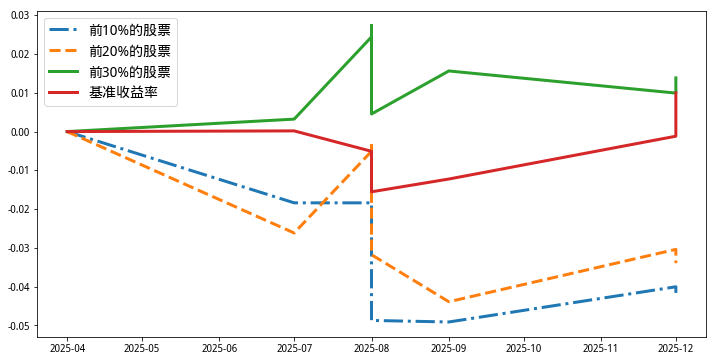

In [91]:
Return = pd.DataFrame(index = all_return["time"])

Return["前10%的股票"] = (all_return["1"].values + 1).cumprod()-1
Return["前20%的股票"] = (all_return["2"].values + 1).cumprod()-1
Return["前30%的股票"] = (all_return["3"].values + 1).cumprod()-1

Return["基准收益率"] = (all_return["日内收益率"].values + 1).cumprod()-1

earliest_date = Return.index.min()
Return.loc[earliest_date, :] = 0

plt.figure(figsize=(12, 6))
plt.plot(Return["前10%的股票"], linestyle='-.',lw=3, label="前10%的股票")
plt.plot(Return["前20%的股票"], linestyle='--',lw=3, label="前20%的股票")
plt.plot(Return["前30%的股票"], linestyle='-',lw=3, label="前30%的股票")
plt.plot(Return["基准收益率"],lw=3, label="基准收益率")
plt.legend(fontsize=14)

plt.show()

In [97]:
Return["超额收益率"] = Return["前10%的股票"] - Return["基准收益率"]

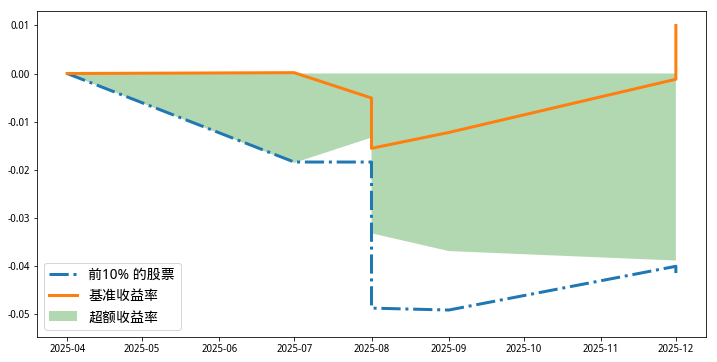

In [99]:
# Return = Return.iloc[]
plt.figure(figsize=(12, 6))
plt.plot(Return["前10%的股票"], linestyle='-.', lw=3, label="前10% 的股票")
plt.fill_between(Return.index, 0, Return["超额收益率"], facecolor='green', alpha=0.3, label="超额收益率")
plt.plot(Return["基准收益率"], lw=3, label="基准收益率")
plt.legend(fontsize=14)
# Return.plot(figsize = (10, 5), legend= True)
plt.savefig("回测结果.png", dpi=500, bbox_inches = 'tight')#解决图片不清晰，不完整的问题
plt.show()

In [101]:
del all_return["time"]

In [102]:
# 最大回撤
def drawdown(r):
    index = 1000 * (1 + r).cumprod()
    highwatermark = index.cummax()    # .cummax是找到当前节点之前的最大收益率
    drawdowns = (index - highwatermark) / highwatermark        # 计算回撤
    maxdrawdown = drawdowns.min()
    return maxdrawdown


MDD = drawdown(all_return)
MDD = pd.DataFrame(MDD*100, columns=["最大回撤%"])
MDD

,最大回撤%
1,-4.456983
2,-4.045825
3,-2.222222
日内收益率,-1.570347


In [103]:
# 累计收益率
TR = pd.DataFrame(Return.iloc[-1, ].values[:4]*100, index=["1", "2", "3", "基准"], columns=["累计收益率"])
TR

,累计收益率
1,-4.161166
2,-3.394339
3,1.384219
基准,0.997259


In [104]:
# 年化收益率
def annualizedRet(r, year_days):
    cum_return = (1 + r).prod()
    total_days = r.shape[0]
    Annual_Returns = cum_return ** (year_days / total_days) - 1
    return Annual_Returns

AR = annualizedRet(all_return, 4)
AR = pd.DataFrame(AR*100, columns=["年化收益率%"])
AR

,年化收益率%
1,-1.871258
2,-1.523075
3,0.612860
日内收益率,0.442005


In [105]:
# 年化波动率
def annualizedVol(r, year_days, downside = False):
    if downside:
        semistd = r[r < 0].std()
        return semistd * (year_days ** 0.5)
    else:
        return r.std() * (year_days ** 0.5)

In [106]:
# 夏普比率
def sharpeRatio(r, rf, year_days):
    # 将无风险收益率转换成日收益率，然后才能进行相加或者相减
    rf = (1 + rf) ** (1 / year_days) - 1
    excessRets = r - rf
    annExcessRets = annualizedRet(excessRets, year_days)
    annVol = annualizedVol(r, year_days)
    return annExcessRets / annVol

SR = sharpeRatio(all_return, 0.03/4, 4)
SR = pd.DataFrame(SR, columns=["夏普比率"])
SR

,夏普比率
1,-1.565945
2,-0.748767
3,-0.055941
日内收益率,-0.236391


In [107]:
# 索提诺比率
def sortinoRatio(r, rf, year_days):
    rf = (1 + rf) ** (1 / year_days) - 1
    excessRets = r - rf
    annExcessRets = annualizedRet(excessRets, year_days)
    anndownsideVol = annualizedVol(r, year_days, downside=True)
    return annExcessRets / anndownsideVol

SortR= sortinoRatio(all_return, 0.03/4, 4)
SortR = pd.DataFrame(SortR, columns=["索提诺比率"])
SortR

,索提诺比率
1,-1.912298
2,-1.202393
3,-0.072643
日内收益率,-0.602758


In [108]:
# 计算Alpha和beta
from scipy import stats
#计算每日收益率
#收盘价缺失值（停牌），使用前值代替
# rets=(df.fillna(method='pad')).apply(lambda x:x/x.shift(1)-1)[1:]
# rets.head()
rets = all_return
#市场指数为x，个股收益率为y
x=all_return.loc[:,"日内收益率"].values
y=all_return.iloc[:,:-1].values
# print(y)
AB=pd.DataFrame()
alpha=[]
beta=[]
for i in range(3):
#使用scipy库中的stats.linregress线性回归，
#python回归有多种实现方式，
#如statsmodels.api的OLS，sklearn库等等
    b,a,r_value,p_value,std_err=stats.linregress(x,y[:,i])
    #alpha转化为年化
    alpha.append(round(a*4,3))
    beta.append(round(b,3))
AB['alpha']=alpha
AB['beta']=beta
AB.index=rets.columns[:-1]
#输出结果：
AB

,alpha,beta
1,-0.023,0.892
2,-0.017,0.436
3,0.006,0.012


In [109]:
###信息比率
#超额收益率以指数收益率或其他为基准
#这里以沪深300为基准
ex_return=pd.DataFrame()
ex_return['1']=rets.iloc[:,0]-rets.iloc[:,3]
ex_return['2']=rets.iloc[:,1]-rets.iloc[:,3]
ex_return['3']=rets.iloc[:,2]-rets.iloc[:,3]

#计算信息比率
information=np.sqrt(len(ex_return))*ex_return.mean()/ex_return.std()
#信息比率的输出结果
INR=pd.DataFrame(information,columns=['信息比率'])
INR

,信息比率
1,-2.885931
2,-0.952685
3,0.103058


In [113]:
indicators.info()
indicators.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 1 to 日内收益率
Data columns (total 8 columns):
累计收益率     4 non-null float64
年化收益率%    4 non-null float64
夏普比率      4 non-null float64
索提诺比率     4 non-null float64
最大回撤%     4 non-null float64
alpha     3 non-null float64
beta      3 non-null float64
信息比率      3 non-null float64
dtypes: float64(8)
memory usage: 360.0+ bytes


,累计收益率,年化收益率%,夏普比率,索提诺比率,最大回撤%,alpha,beta,信息比率
1,-4.161166,-1.871258,-1.565945,-1.912298,-4.456983,-0.023,0.892,-2.885931
2,-3.394339,-1.523075,-0.748767,-1.202393,-4.045825,-0.017,0.436,-0.952685
3,1.384219,0.612860,-0.055941,-0.072643,-2.222222,0.006,0.012,0.103058
基准,0.997259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
日内收益率,NaN,0.442005,-0.236391,-0.602758,-1.570347,NaN,NaN,NaN


In [115]:
indicators=pd.concat([TR, AR, SR, SortR, MDD, AB, INR],axis=1, join='outer',sort='False')
#结果保留三位小数
indicators = indicators.head(len(indicators)-1)
indicators.index = ["前10%的股票","前20%的股票", "前30%的股票","基准"]
indicators.round(3)


,累计收益率,年化收益率%,夏普比率,索提诺比率,最大回撤%,alpha,beta,信息比率
前10%的股票,-4.161,-1.871,-1.566,-1.912,-4.457,-0.023,0.892,-2.886
前20%的股票,-3.394,-1.523,-0.749,-1.202,-4.046,-0.017,0.436,-0.953
前30%的股票,1.384,0.613,-0.056,-0.073,-2.222,0.006,0.012,0.103
基准,0.997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
